In [8]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp

In [9]:
Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-08-20_ConvNextUNetTrain3Dv021Eval3DEpochs70Epoch70_Train_global_3D_Test_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_4000_rand_seed_1.zarr'


In [10]:
dates = np.array([  3,   8,  13,  18,  23,  28,  33,  38,  43,  48,  53,  58,  63,
        68,  73,  78,  83,  88,  93,  98, 103, 108, 113, 118, 123, 128,
       133, 138, 143, 148, 153, 158, 163, 168, 173, 178, 183, 188, 193,
       198, 203, 208, 213, 218, 223, 228, 233, 238, 243, 248, 253, 258,
       263, 268, 273, 278, 283, 288, 293, 298, 303, 308, 313, 318, 323,
       328, 333, 338, 343, 348, 353, 358, 363])

def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

import os
import pandas as pd

levels = 19
emulation_stability=True
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = np.array([np.datetime64('1996') + np.timedelta64(day-1,'D') for day in dates])
    for i in range(1,repeats):
        new_time = np.hstack((new_time,np.array([np.datetime64(str(1996+i)) + np.timedelta64(day-1,'D') for day in dates])))
    # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time[:7300]
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7003))
else:
    ds_groundtruth = ds_input.isel(time=slice(4143, 4743)).isel(lev=slice(None, levels))


ls = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']

# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-08-20_ConvNextUNetTrain3Dv021Eval3DEpochs70Epoch70_Train_global_3D_Test_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_4000_rand_seed_1.zarr'
Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-03_ConvNextUNetTrain3DEval3DHist1Epoch70Years100-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr'
output_folder = Pred_path.split("/")[-2].split("_Train")[0]
output_path = os.path.join("./temp", output_folder)

if os.path.isdir(output_path):
    print("Using Output Folder : ", output_path)
else:
    print("Using Output Folder : ../outputs")
    output_path = "../outputs"

ds_prediction_raw = xr.open_zarr(Pred_path)

# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_raw.time.size))

ds_prediction = post_processor(
    ds_prediction_raw, ds_groundtruth, ls
)

# Run the test to make sure the output is formatted correctly


/tmp/ipykernel_247162/574389072.py:75: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth['time'] = new_time[:7300]
/tmp/ipykernel_247162/574389072.py:75: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosec

Using Output Folder : ../outputs


/global/homes/a/asubel/.conda/envs/NERSC_Kernel/lib/python3.12/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


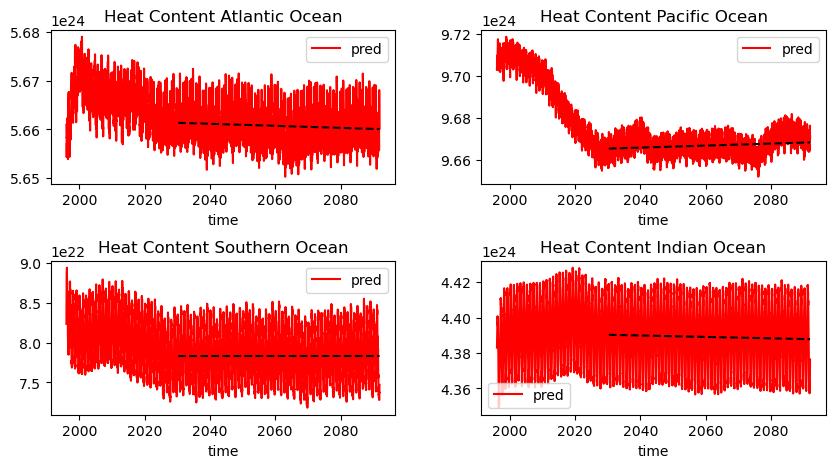

In [20]:
# Compute Basin Heat Content Time Series

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,ds_prediction)

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred = ((ds_prediction['thetao']*c_p*rho_0*masks[var])*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    

    OHC_pred.plot(ax = ax_flat[i], label = 'pred', c = 'r')
    ax_flat[i].legend()
    ax_flat[i].set_title("Heat Content " + var + " Ocean")
    coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[2500:].size), OHC_pred[2500:], 1)
    ax_flat[i].plot(OHC_pred[2500:].time.data, np.arange(OHC_pred[2500:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')

# fig.savefig('./figures/OHC_Short.png',dpi=250)

In [ ]:
# Compute Basin Heat Content Time Series

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred = ((ds_prediction['thetao']*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred = OHC_pred.rename('Ocean Heat Content')
OHC_pred = OHC_pred.assign_attrs(units = 'J')

OHC_pred.plot(ax = ax, label = 'pred', c = 'r')
ax.legend()
ax.set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[2500:].size), OHC_pred[2500:], 1)
ax.plot(OHC_pred[2500:].time.data, np.arange(OHC_pred[2500:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')



Text(0.5, 0.98, 'Depth Profile Drake Passage at Lon = 330')

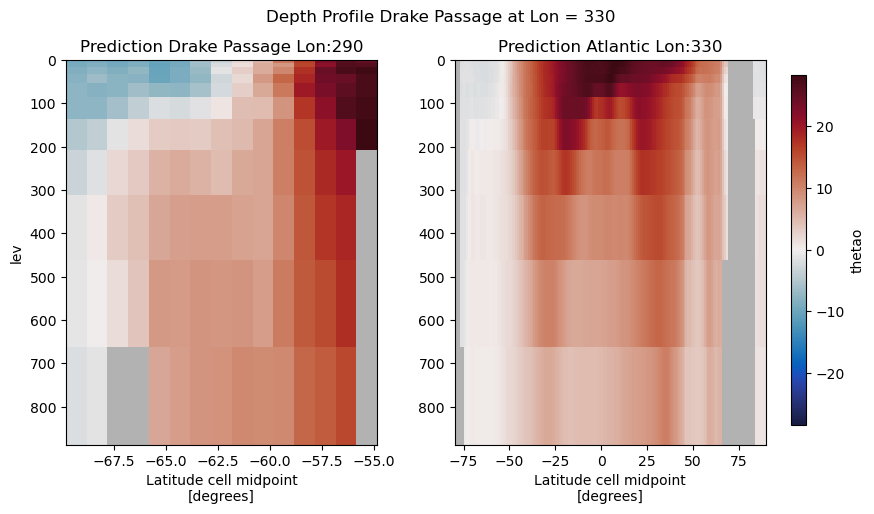

In [28]:
#Drake Passage Full Depth 

# new_cmap = cm.cm.thermal 
new_cmap = cm.cm.balance 

new_cmap.set_bad('grey',.6)

day_start = -100
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = True

fig, ax = plt.subplots(1,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1], 'wspace': 0.25,'hspace':.5})
bounds = regions['Drake Passage']
var = 'thetao'
if surface:
    level_slice = slice(0,1000)
else:
    level_slice = slice(None)

pred_plot = ds_prediction[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time').plot(y = 'lev',ax=ax[0],add_colorbar=False,cmap = new_cmap)
ax[0].invert_yaxis()
ax[0].set_title('Prediction Drake Passage Lon:' +  str(bounds['lon']))

bounds = regions['Atlantic']
pred_plot = ds_prediction[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time').plot(y = 'lev',ax=ax[1],add_colorbar=False,cmap = new_cmap)
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].set_title('Prediction Atlantic Lon:' +  str(bounds['lon']))

fig.subplots_adjust(right=0.825)
cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
cbar = fig.colorbar(pred_plot, cax=cbar_ax)
cbar.set_label(var,rotation = 90)
fig.suptitle(r"Depth Profile " +region + " at Lon = " + str(bounds['lon']) )